<a href="https://colab.research.google.com/github/williamokomba/lx_lesson3/blob/main/Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matplotlib Tutorial

In [ ]:
#import libraries
import pandas as pd
import numpy as np

#import matplotlib
import matplotlib.pyplot as plt

In [ ]:
#load and read the dataset
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# check the null values
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
#impute age with median, and cabin with mode
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
cabin_mode = df["Cabin"].mode()[0]

#impute with the mode
df["Cabin"] = df["Cabin"].fillna(cabin_mode)

#confirm
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64

In [ ]:
#drop any null value in the remaining columns
df.dropna(inplace=True)

#confirm
df.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [ ]:
#check duplicate
df.duplicated().sum()

np.int64(0)

## Matplotlib

1. plt
2. fig, ax

### 1. Bar chart

we use on categorical columns, or 2 cat, or cat and numerical column

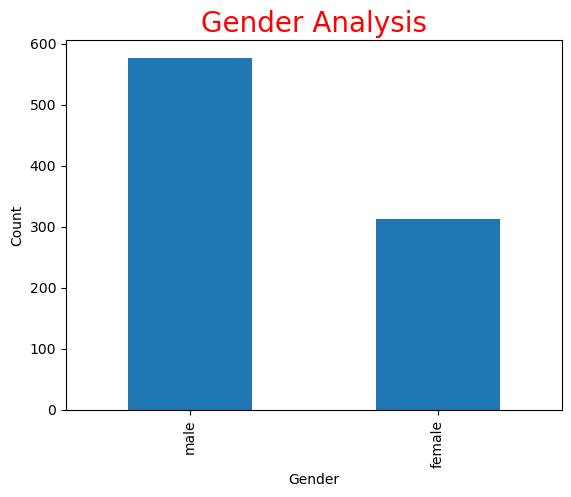

In [ ]:
#get the gender composition
gender_count = df["Sex"].value_counts().plot(kind= "bar"), #we can have horizontal bar by adding kind="barh"

plt.title("Gender Analysis", fontsize= 20, color= "r")
plt.ylabel("Count")
plt.xlabel("Gender")
plt.show()

### Pie chart
use it only on categorical columns with maximum of 4 sub-category

Note: avoid it if necessary since it is hard to interprent some times.

Sex
male      577
female    312
Name: count, dtype: int64


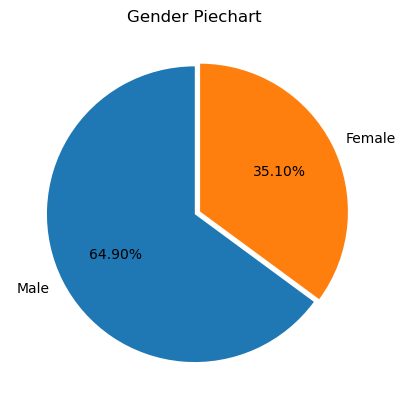

In [ ]:
#pie chart
value_c = df['Sex'].value_counts()
print(value_c)
exlode_var = [0.0, 0.04]
label = ["Male", "Female"] # adding the category to the , we can also assign lable by Labels = value_c.index
plt.pie(value_c, autopct='%.2f%%', labels=label, explode=exlode_var, startangle=90)
plt.title("Gender Piechart")
plt.show()

### Donut chart

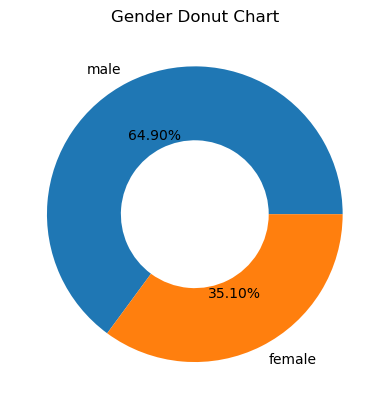

In [ ]:
plt.pie(value_c, autopct='%.2f%%', labels=value_c.index, wedgeprops=dict(width=.5))
plt.title("Gender Donut Chart")
plt.show()

In [ ]:
plt.xlim?

### LIne plot
only use it when checking for trends, i.e on year, month, day, quarter, tiem etc

always use groupby or pivot table while dealing with line plot

In [ ]:
df2 = pd.read_csv("sample_one.csv")

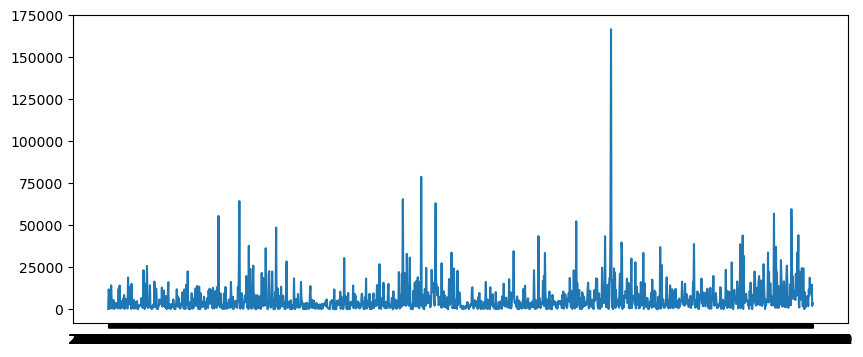

In [ ]:
#plot sales by order date
plt.figure(figsize=(10,4))
sales_gr = df2.groupby('Order Date')["Sales"].sum()

plt.plot(sales_gr);

In [ ]:
#convert order date to date time
from datetime import datetime

df2["year"] = pd.to_datetime(df2['Order Date']).dt.year

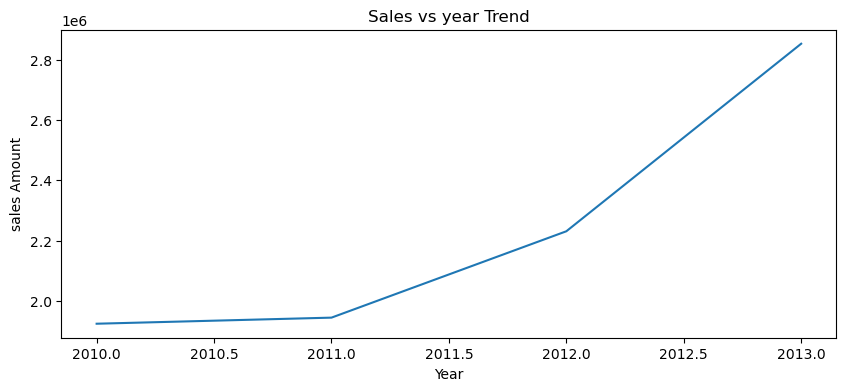

In [ ]:
plt.figure(figsize=(10,4))
sales_gr = df2.groupby('year')["Sales"].sum()
plt.plot(sales_gr)
plt.title( "Sales vs year Trend")
plt.xlabel("Year")
plt.ylabel("sales Amount");


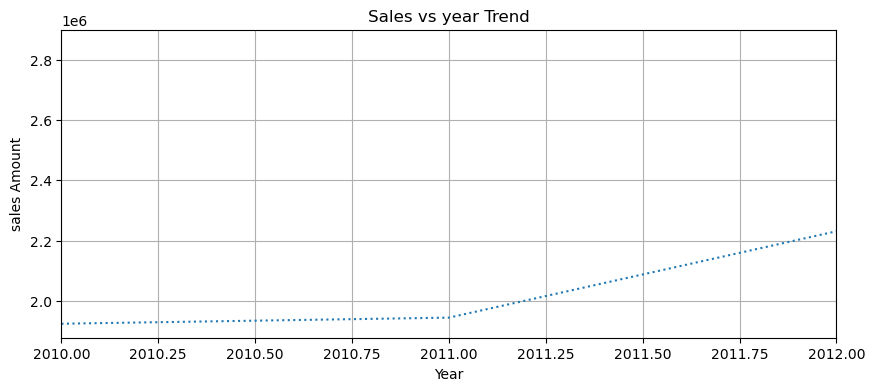

In [ ]:
#how to use y and xlim to zoom into specific values using dotted linestyle
plt.figure(figsize=(10,4))
sales_gr = df2.groupby('year')["Sales"].sum()
plt.plot(sales_gr, linestyle="dotted")
left = 2010
right = 2012
plt.xlim(left, right)
plt.title( "Sales vs year Trend")
plt.xlabel("Year")
plt.ylabel("sales Amount")
plt.grid();

In [ ]:
df2.columns

Index(['Row ID', 'Order Priority', 'Discount', 'Unit Price', 'Shipping Cost',
       'Customer ID', 'Customer Name', 'Ship Mode', 'Customer Segment',
       'Product Category', 'Product Sub-Category', 'Product Container',
       'Product Name', 'Product Base Margin', 'Region', 'State or Province',
       'City', 'Postal Code', 'Order Date', 'Ship Date', 'Profit',
       'Quantity ordered new', 'Sales', 'Order ID', 'year'],
      dtype='object')

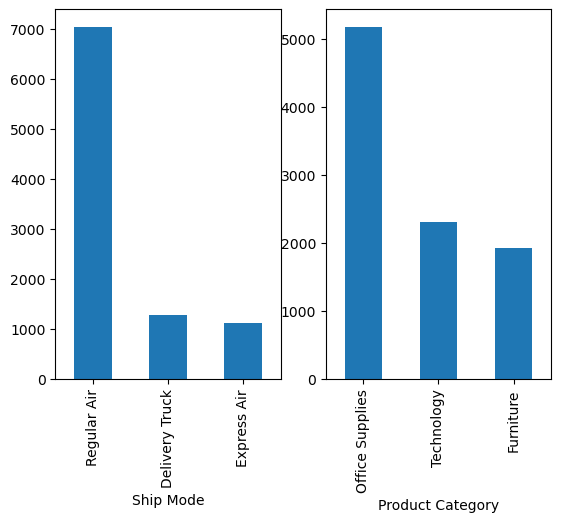

In [ ]:
#plot 2 visual represing 2 coulms
plt.subplot(1,2, 1)
df2['Ship Mode'].value_counts().plot(kind="bar");

plt.subplot(1,2,2)
df2['Product Category'].value_counts().plot(kind="bar");

### Scatter plot, this help us to checjk on correlation/relationship btn or among varraibles
 This is used on 2 numeric columns or 2 numeric and 1 categorical
    

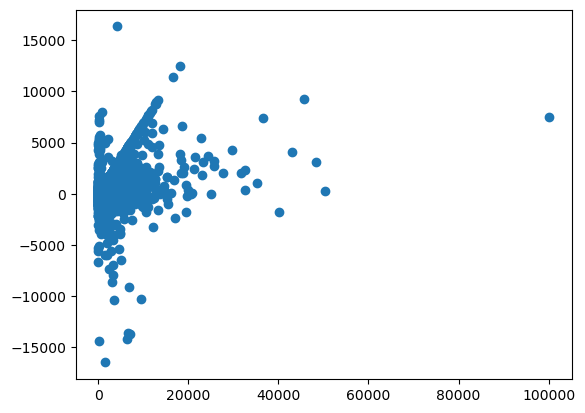

In [ ]:
#scatter plot
plt.scatter(df2["Sales"], df2["Profit"]);

### Histogram
* This is used to check distribution of the dataset
* It is used of numerical columns(Distrete datatype)


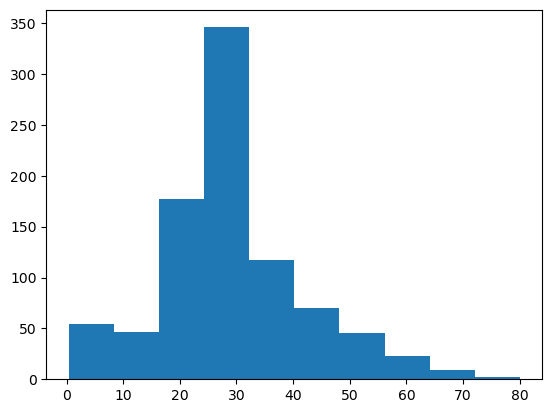

In [ ]:
#use the first dataset for this demonstration
plt.hist(df["Age"])
plt.show()

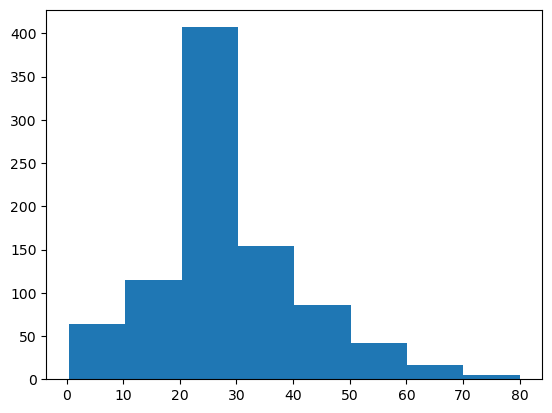

In [ ]:
#adding bins to the hist
plt.hist(df["Age"], bins=8);

### Box plot
This is used on numeric data types to check for outliers

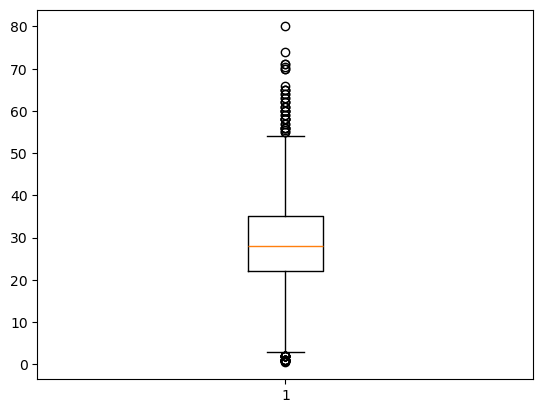

In [ ]:
#box plot
plt.boxplot(df["Age"]);

## fig, ax approach

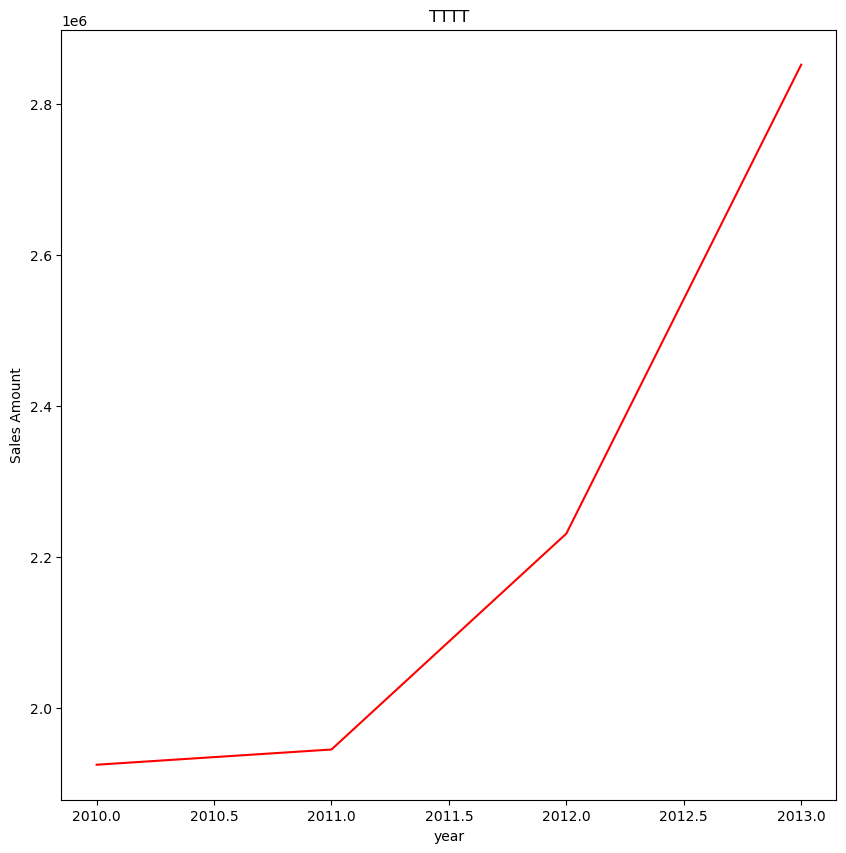

In [ ]:
#ploting the visual
fig, ax = plt.subplots(figsize=(10,10))
ax.plot(sales_gr, color="r")
ax.set_title("TTTT")
ax.set_xlabel("year")
ax.set_ylabel("Sales Amount")
plt.show()

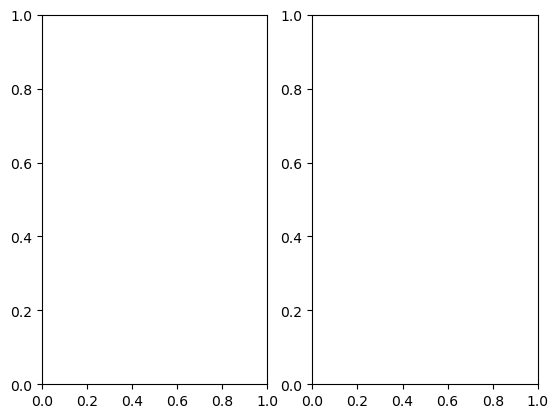

In [ ]:
#creating subplots in this approach
fig, ax = plt.subplots(1,2)



<Axes: xlabel='Region'>

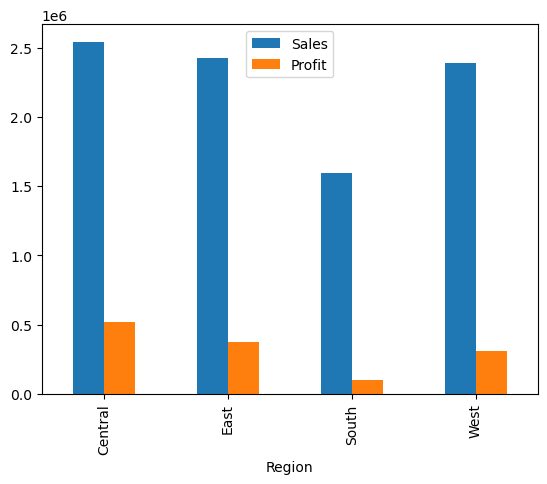

In [ ]:
sl_grb =df2.groupby("Region")[["Sales", "Profit"]].sum()
sl_grb.plot(kind="bar")

## Visualization using Seaborn

seaborn is build on top of matplotlibb

In [ ]:
#import seaborn as sns
import seaborn as sns

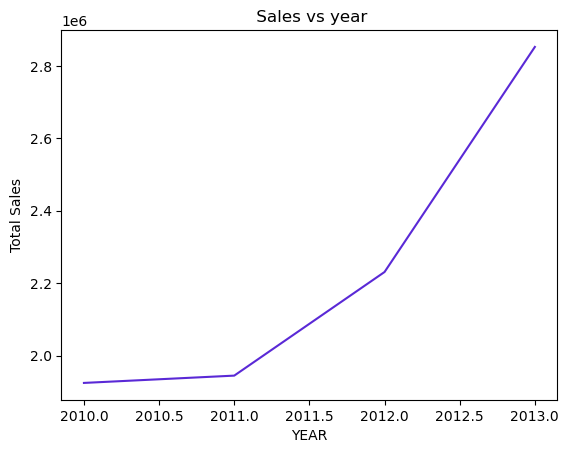

In [ ]:
#lineplot
sns.lineplot(sales_gr, color="#5a29d6")
plt.title(" Sales vs year")
plt.xlabel("YEAR")
plt.ylabel("Total Sales")
plt.show()

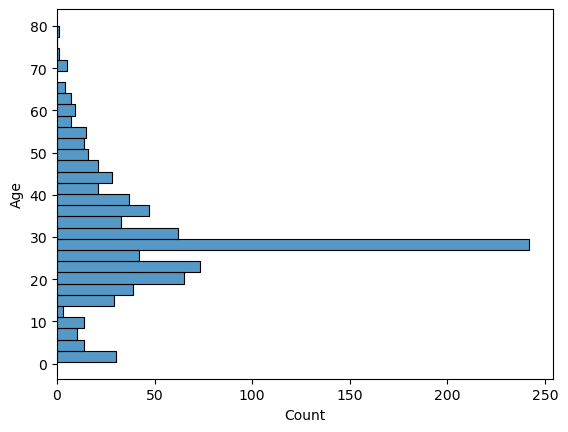

In [ ]:
#option 2
#having hozintontal Visual
sns.histplot(y =df["Age"]);

<Axes: xlabel='Age', ylabel='Count'>

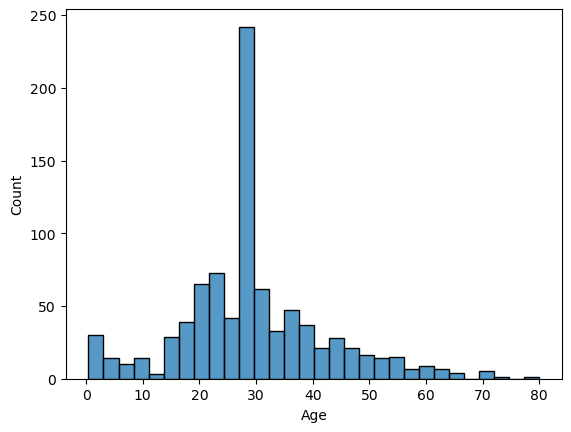

In [ ]:
#option3
sns.histplot(x = "Age", data=df)

<Axes: ylabel='Age'>

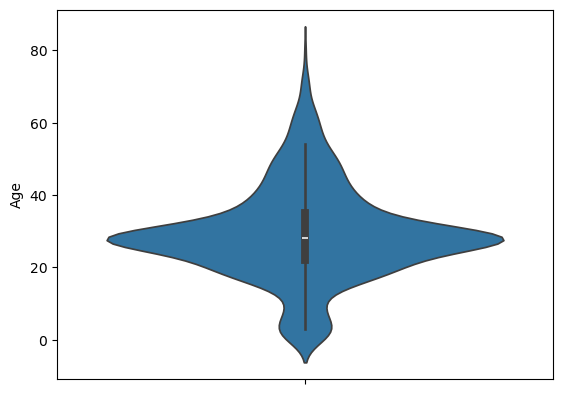

In [ ]:
##violin plot
sns.violinplot(y= "Age", data=df)

<Axes: xlabel='Sales', ylabel='Profit'>

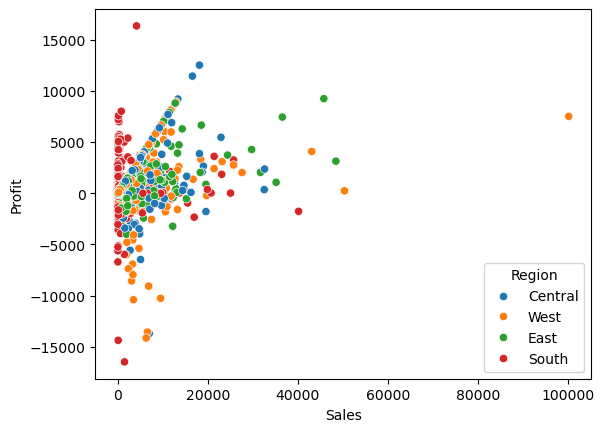

In [ ]:
# get analysis on Seales, profit, vs shipmode

sns.scatterplot(x = "Sales", y= "Profit", hue= "Region", data=df2)

<Axes: ylabel='Sales'>

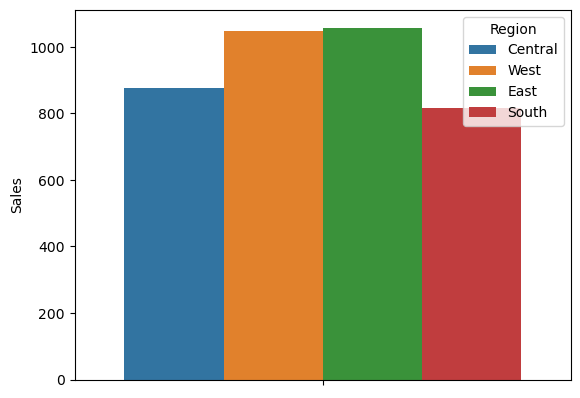

In [ ]:
#using hue on 2 variables

sns.barplot(y="Sales", hue="Region", data=df2, errorbar=None)

<Axes: xlabel='Region'>

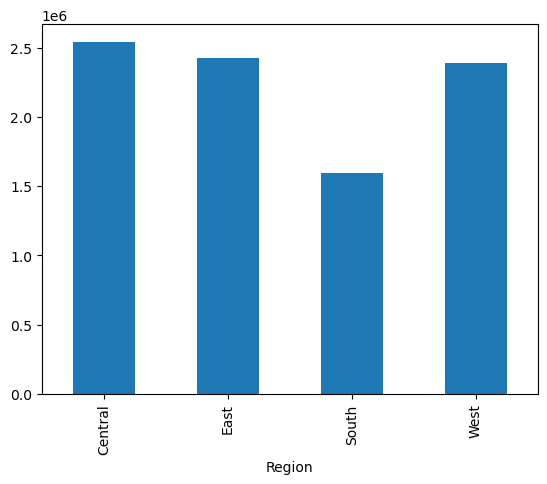

In [ ]:
df2.groupby("Region")["Sales"].sum().plot(kind="bar")

<Axes: xlabel='Region'>

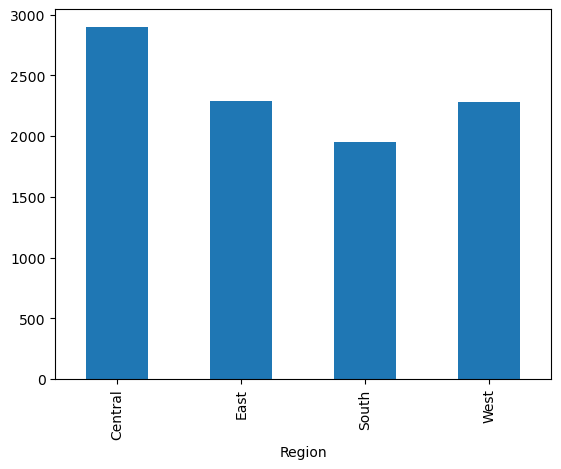

In [ ]:
df2.groupby("Region")["Region"].count().plot(kind= "bar")

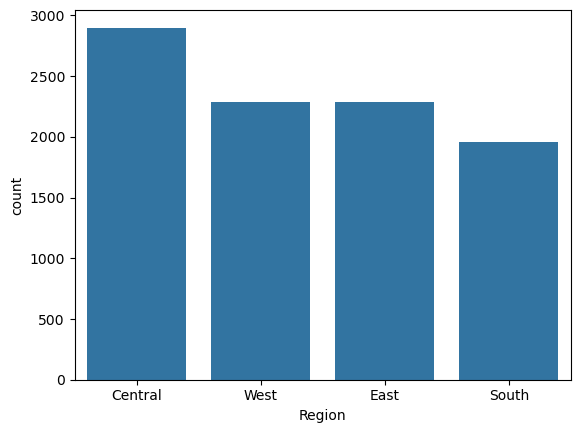

In [ ]:
#in seaborn
sns.countplot(x="Region", data=df2);

In [ ]:
#pair plot

#sns.pairplot(df2["Sales"], hue="Region")

In [ ]:
#correlation heatmap
df2.dropna(inplace= True)
numeric_df = df2.select_dtypes("number")
numeric_df

,Row ID,Discount,Unit Price,Shipping Cost,Customer ID,Product Base Margin,Postal Code,Profit,Quantity ordered new,Sales,Order ID,year
0,18606,0.01,2.88,0.50,2,0.36,60101,1.320000,2,5.90,88525,2012
1,20847,0.01,2.84,0.93,3,0.54,98221,4.560000,4,13.01,88522,2010
2,23086,0.03,6.68,6.15,3,0.37,98221,-47.640000,7,49.92,88523,2011
3,23087,0.01,5.68,3.60,3,0.56,98221,-30.510000,7,41.64,88523,2011
4,23088,0.00,205.99,2.50,3,0.59,98221,998.202300,8,1446.67,88523,2011
...,...,...,...,...,...,...,...,...,...,...,...,...
9421,20275,0.06,35.89,14.72,3402,0.40,25314,137.860000,13,447.87,87532,2013
9422,20276,0.00,3.34,7.49,3402,0.54,25314,-39.070000,3,13.23,87532,2013
9423,24491,0.08,550.98,45.70,3402,0.71,25314,-1225.029097,4,2215.93,87533,2013
9424,25914,0.10,105.98,13.99,3403,0.65,82001,349.485000,5,506.50,87530,2010


In [ ]:
#compute correlation

numeric_df.corr()

,Row ID,Discount,Unit Price,Shipping Cost,Customer ID,Product Base Margin,Postal Code,Profit,Quantity ordered new,Sales,Order ID,year
Row ID,1.000000,0.002768,0.007344,0.004006,0.038956,-0.002013,0.034135,-0.006241,-0.574534,-0.219326,0.918472,0.061009
Discount,0.002768,1.000000,0.000287,-0.003857,-0.004144,0.006801,-0.001219,-0.039627,-0.014252,-0.022212,0.002100,0.009835
Unit Price,0.007344,0.000287,1.000000,0.244054,-0.007442,0.061917,0.023119,-0.050743,-0.054534,0.433973,0.009527,-0.017377
Shipping Cost,0.004006,-0.003857,0.244054,1.000000,-0.014768,0.377359,-0.003023,-0.019150,-0.019537,0.308490,0.006170,0.002242
Customer ID,0.038956,-0.004144,-0.007442,-0.014768,1.000000,-0.020397,-0.086815,0.007757,-0.028558,-0.005367,0.043528,0.000309
Product Base Margin,-0.002013,0.006801,0.061917,0.377359,-0.020397,1.000000,-0.004380,-0.070798,0.000205,0.117908,0.006821,-0.012805
Postal Code,0.034135,-0.001219,0.023119,-0.003023,-0.086815,-0.004380,1.000000,0.004851,-0.009838,0.001276,0.037973,0.022952
Profit,-0.006241,-0.039627,-0.050743,-0.019150,0.007757,-0.070798,0.004851,1.000000,0.123151,0.371044,-0.003742,0.013989
Quantity ordered new,-0.574534,-0.014252,-0.054534,-0.019537,-0.028558,0.000205,-0.009838,0.123151,1.000000,0.357158,-0.599095,0.026605
Sales,-0.219326,-0.022212,0.433973,0.308490,-0.005367,0.117908,0.001276,0.371044,0.357158,1.000000,-0.226968,-0.001432


In [ ]:
#getting color themes from matplotlib
print(plt.colormaps(), end=" ")

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

<Axes: >

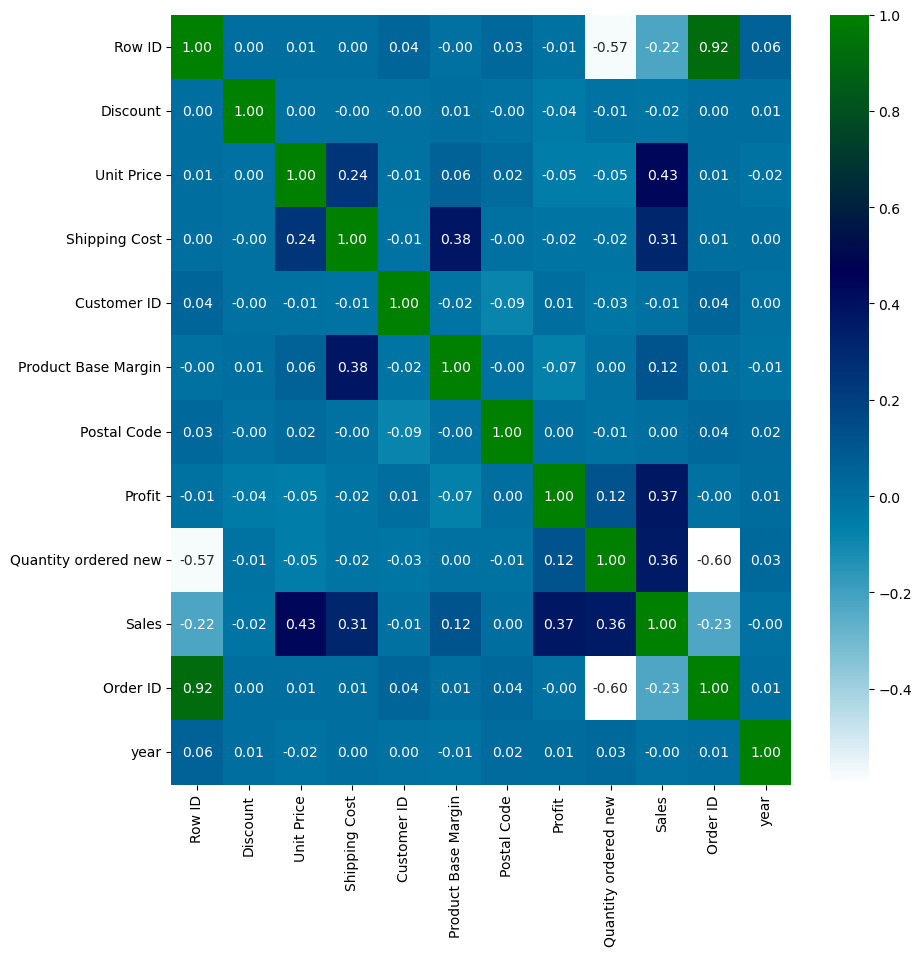

In [ ]:
#visualize corr
corr = numeric_df.corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="ocean_r")